In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from pandas.plotting import parallel_coordinates

# Load dataset Iris dari scikit-learn
iris = load_iris()

Kode berikut digunakan untuk memanggil beberapa library yang diperlukan dalam praktikum K-Nearest Neighbors. numpy digunakan untuk membantu pengolahan data numerik dan array, pandas digunakan untuk mengolah dataset dalam bentuk DataFrame, sedangkan matplotlib.pyplot digunakan untuk membuat visualisasi data. load_iris digunakan untuk mengambil dataset Iris yang sudah tersedia pada Scikit-Learn, sementara parallel_coordinates digunakan untuk membuat visualisasi Parallel Coordinates pada dataset Iris.

In [2]:
# Konversi data menjadi DataFrame Pandas
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["Species"] = iris.target_names[iris.target]

# Definisikan X (fitur) dan y (target/Label)
X = df.drop(columns=["Species"])
y = df["Species"]

print(X)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]


Bagian code berikut digunakan untuk mengubah data fitur Iris menjadi DataFrame Pandas. empat fitur akan digunakan. Setelah itu digunakan untuk menambahkan kolom Species yang berisi nama jenis bunga
Variabel X berisi fitur/input digunakan untuk melakukan klasifikasi

In [3]:
y

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: Species, Length: 150, dtype: str

output berikut adalah label atau target dari setiap data. Label menunjukkan species bunga yang sesuai dengan data pada X.

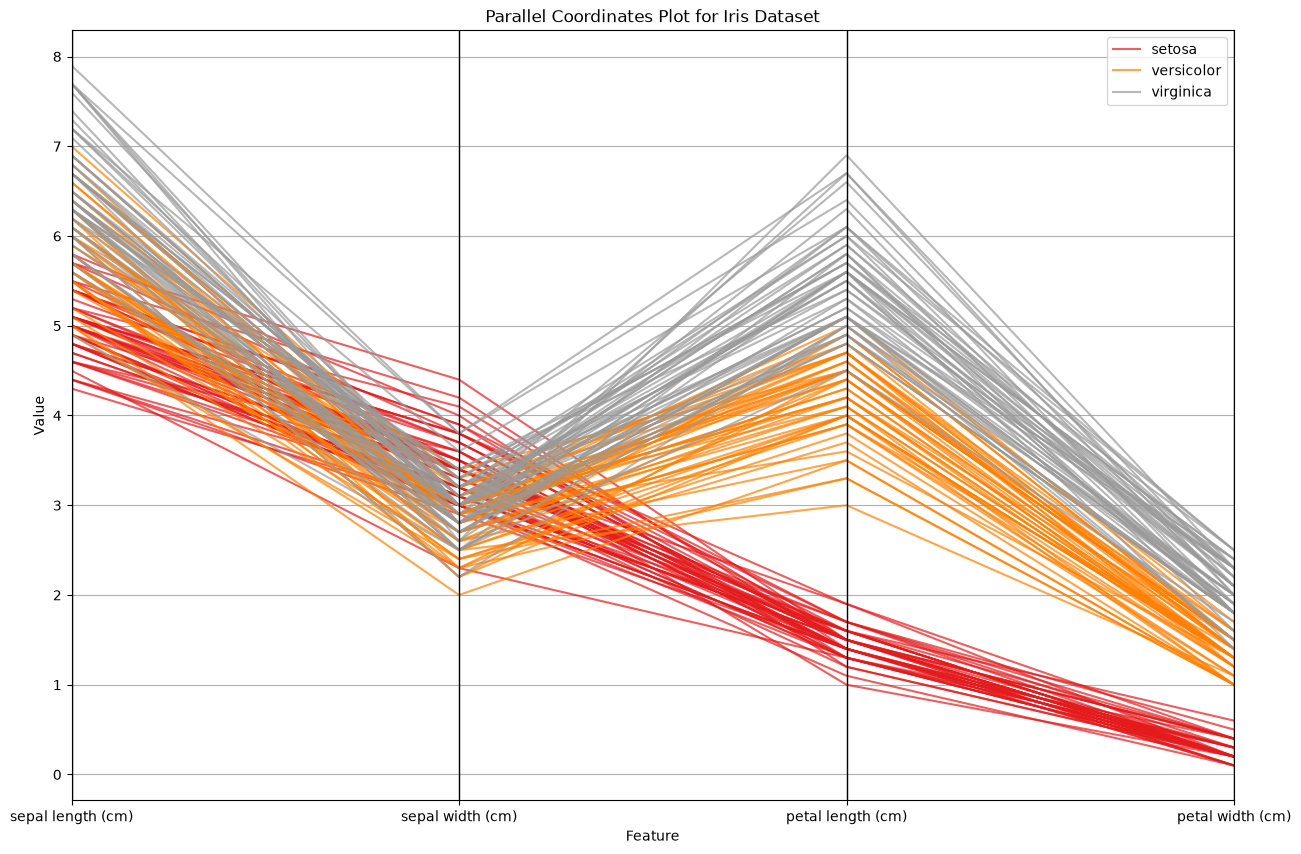

In [5]:
# Plot Parallel Coordinates
plt.figure(figsize=(15, 10))

parallel_coordinates(df, class_column="Species", colormap=plt.cm.Set1, alpha=0.7)
plt.title("Parallel Coordinates Plot for Iris Dataset")
plt.xlabel("Feature")
plt.ylabel("Value")
plt.grid(True)
plt.show()

Grafik memperlihatkan pola masing-masing species berdasarkan empat fitur iris. Setiap garis mewakili satu data bunga dan kelompok garis menunjukkan perbedaan karakteristik antar-species

In [6]:
from sklearn.preprocessing import LabelEncoder
lab = LabelEncoder()
y = lab. fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

sebelum y berisi teks, algoritma KNN membutuhkan label yang dapat diporses secara numerik, sehingga digunakan LabelEncoder.output berikut menjelasakn representasi numerik dari ketiga species bunga tersebut

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X, test_size=0.2, random_state=0)
y_train, y_test = train_test_split(y, test_size=0.2, random_state=0)

Data dibagi menjadi data training dan data testing, digunakan sekitar 20% untuk pengujian. Sedangkan random_state=0 digunakan agar pembagian data dapat menghasilkan pembagian yang sama ketika kode dijalankan kembali

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# k = 3
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


Code berikut digunakan untuk membuat model KNN. accuracy_score digunakan untuk menghitung tingkat akurasi hasil klasifikasi. Model KNN dibuat dengan menggunakan 3 tetangga terdekat. metric="euclidean" menggunakan jarak Euclidean untuk menentukan kedekatan data

In [9]:
y_pred = knn.predict(X_test)
y_pred

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 2, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

Model digunakan untuk memprediksi species dari data yang terdapat pada X_test,Angka tersebut merupakan hasil klasifikasi:
0 = setosa
1 = versicolor
2 = virginica

In [10]:
result = accuracy_score(y_test, y_pred)
result

0.9666666666666667

Code berikut berisi nilai jika dikonversikan menjadi persentase adalah:
96,67%
Artinya, model KNN berhasil mengklasifikasikan sekitar 96,67% data testing dengan benar pada percobaan praktikum tersebut

In [12]:
df = pd.read_csv('athletes.xls')
print(df)

    id  speed  agility draft
0    1   2.50     6.00    no
1    2   3.75     8.00    no
2    3   2.25     5.50    no
3    4   3.25     8.25    no
4    5   2.75     7.50    no
5    6   4.50     5.00    no
6    7   3.50     5.25    no
7    8   3.00     3.25    no
8    9   4.00     4.00    no
9   10   4.25     3.75    no
10  11   2.00     2.00    no
11  12   5.00     2.50    no
12  13   8.25     8.50    no
13  14   5.75     8.75   yes
14  15   4.75     6.25   yes
15  16   5.50     6.75   yes
16  17   5.25     9.50   yes
17  18   7.00     4.25   yes
18  19   7.50     8.00   yes
19  20   7.25     5.75   yes


Code berikut digunakan untuk membuka file athletes.csv menggunakan Pandas.

In [13]:
feature_columns = ['speed', 'agility']
X = df[feature_columns ]. values
y = df['draft' ].values

Fitur ini digunakan untuk melakukan prediksi speed,agility sedangkan draft digunakan sebagai target. Jadi model akan belajar hubungan antara kecepatan dan kelincahan atlet dengan status draft.

In [14]:
X

array([[2.5 , 6.  ],
       [3.75, 8.  ],
       [2.25, 5.5 ],
       [3.25, 8.25],
       [2.75, 7.5 ],
       [4.5 , 5.  ],
       [3.5 , 5.25],
       [3.  , 3.25],
       [4.  , 4.  ],
       [4.25, 3.75],
       [2.  , 2.  ],
       [5.  , 2.5 ],
       [8.25, 8.5 ],
       [5.75, 8.75],
       [4.75, 6.25],
       [5.5 , 6.75],
       [5.25, 9.5 ],
       [7.  , 4.25],
       [7.5 , 8.  ],
       [7.25, 5.75]])

pada code berikut setiap baris mewakili satu atlet yang berarti atlet tersebut memiliki speed = 2.50, dan agility = 6.00

In [15]:
y

<StringArray>
[ 'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',
  'no',  'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes']
Length: 20, dtype: str

code berikut kolom draft merupakan target yang ingin diprediksi oleh model.

In [16]:
#encode data y menjadi numerik

en = LabelEncoder()
y = en.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1])

Kode tersebut digunakan untuk mengubah label yes dan no menjadi angka agar dapat diproses oleh algoritma KNN. Hasil encoding menunjukkan bahwa label no diubah menjadi angka 0, sedangkan label yes diubah menjadi angka 1. Dengan perubahan tersebut, model dapat melakukan proses klasifikasi menggunakan data numerik.

['r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'g' 'g' 'g' 'g' 'g'
 'g' 'g']


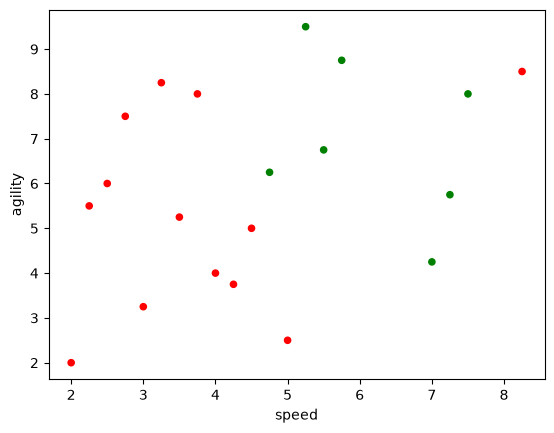

In [17]:
from numpy import where
df['key1'] =(y)
colors = np.where(df["key1"] == 0,'r','g')
print(colors)
df.plot.scatter(x=1,y=2,c=colors)
plt.show()

Kode tersebut digunakan untuk menampilkan persebaran data atlet dalam bentuk scatter plot. Warna pada setiap titik digunakan untuk membedakan atlet yang berstatus no dan yes, sehingga visualisasi dapat membantu melihat pola persebaran kedua kelompok data berdasarkan fitur yang digunakan.

In [18]:
# split train test
X_train, X_test = train_test_split(X, test_size=0.2, random_state=0)
y_train, y_test = train_test_split(y, test_size=0.2, random_state=0)

Kode tersebut digunakan untuk membagi dataset atlet menjadi data training dan testing. Sebanyak 20% data digunakan sebagai data testing dan sisanya digunakan sebagai data training. Pembagian data ini dilakukan agar model dapat dilatih menggunakan sebagian data dan kemudian diuji menggunakan data yang tidak digunakan dalam proses pelatihan.

In [19]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)

,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


Kode tersebut digunakan untuk membuat dan melatih model KNN pada dataset atlet. Model menggunakan K=5, yang berarti lima tetangga terdekat akan digunakan dalam menentukan kelas suatu data, sedangkan metric='euclidean' digunakan untuk menghitung jarak antar data. Setelah model dibuat, fit() digunakan untuk melatih model menggunakan data training.

In [20]:
y_pred = knn.predict(X_test)
y_pred

array([1, 1, 1, 0])

Kode tersebut digunakan untuk memprediksi status draft dari data testing. Output yang diperoleh adalah array([1, 1, 1, 0]). Karena sebelumnya 0 menunjukkan no dan 1 menunjukkan yes, maka hasil prediksi tersebut menunjukkan tiga data diprediksi masuk draft dan satu data diprediksi tidak masuk draft.

In [21]:
result = accuracy_score(y_test, y_pred)
result

0.75

Kode tersebut digunakan untuk menghitung akurasi model KNN pada dataset atlet dengan membandingkan hasil prediksi dengan label sebenarnya. Output yang diperoleh adalah 0.75, sehingga akurasi model adalah 75% pada data testing yang digunakan

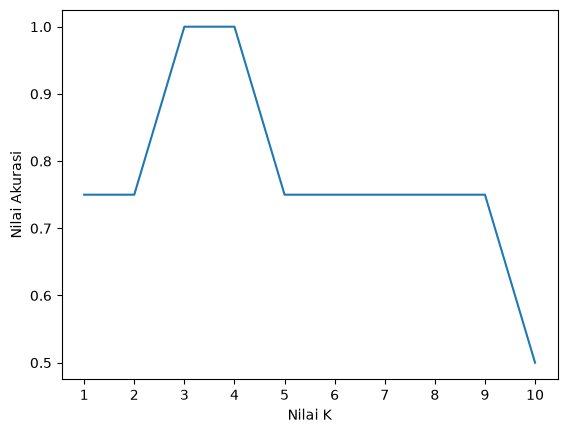

In [23]:
#untuk menemukan nilai K yang tepat, bisa dengan mencoba beberapa variasi nilai K dan melihat

array_k = []
for i in range(1,11):
    knn = KNeighborsClassifier(n_neighbors=i, metric='euclidean')
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    # Calculate accuracy
    result = accuracy_score(y_test, y_pred)

    # Store the accuracy result
    array_k.append(result)

plt.plot(array_k)
plt.ylabel('Nilai Akurasi')

plt.xlabel('Nilai K')
plt.xticks(np.arange(10), ('1','2','3','4','5','6','7','8','9','10'))
plt.show()

code tersebut digunakan untuk membuat grafik yang menunjukkan hubungan antara nilai K dengan akurasi model KNN. Sumbu X menunjukkan nilai K dari 1 sampai 10, sedangkan sumbu Y menunjukkan nilai akurasi yang diperoleh dari setiap nilai K. Grafik ini dapat digunakan untuk melihat nilai K yang memberikan hasil akurasi paling baik berdasarkan data testing yang digunakan

In [ ]:
# NO 1
# 42324042_Tamara Sinaga
# TUGAS PREDIKSI DATASET ATLET

input_data = [[7.5, 7.0],
[4.0, 6.5]]

# Membuat model KNN dengan K=5
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

# Melatih model
knn.fit(X_train, y_train)

# Melakukan prediksi
y_pred_input = knn.predict(input_data)

print("Hasil prediksi:")
print(y_pred_input)


Hasil prediksi:
[1 0]


In [26]:
# Prediksi atlet baru
input_data = [[7.5, 7.0],
[4.0, 6.5]]

# Prediksi
y_pred_input = knn.predict(input_data)

# Mengubah hasil angka menjadi yes/no
hasil = en.inverse_transform(y_pred_input)

print("Hasil prediksi:")
for data, prediksi in zip(input_data, hasil):
    print(f"Input {data} -> {prediksi}")

Hasil prediksi:
Input [7.5, 7.0] -> yes
Input [4.0, 6.5] -> no


Kode tersebut digunakan untuk melakukan prediksi terhadap dua data atlet baru yang diberikan pada tugas, yaitu [7.5, 7.0] dan [4.0, 6.5]. Model yang digunakan adalah KNN dengan K=5 dan jarak Euclidean, sama seperti model yang digunakan pada bagian praktikum dataset atlet. Data baru dimasukkan ke dalam knn.predict() untuk mendapatkan hasil prediksi, kemudian en.inverse_transform() digunakan untuk mengubah hasil numerik kembali menjadi label yes atau no. Berdasarkan model dan data yang digunakan, hasil prediksi yang diperoleh adalah yes untuk [7.5, 7.0] dan no untuk [4.0, 6.5]

In [ ]:
# NO 2 PREDIKSI DATA IRIS
import numpy as np
import pandas as pd

from sklearn. datasets import load_iris
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Load dataset Iris
iris = load_iris()

# Membuat DataFrame
df_iris = pd. DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Menambahkan nama species
df_iris["Species"] = iris.target_names[iris.target]

# Menentukan fitur dan target
X_iris = df_iris.drop(columns=["Species"])
y_iris = df_iris["Species"]

# Encoding target
lab_iris = LabelEncoder()
y_iris = lab_iris.fit_transform(y_iris)

# Membagi data training dan testing
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris,
    y_iris,
    test_size=0.2,
    random_state=0
)

In [34]:
knn_iris = KNeighborsClassifier(
n_neighbors=3,
metric="euclidean"

)

# Training menggunakan DATA IRIS
knn_iris.fit(X_train_iris, y_train_iris)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [35]:
input_data = [
    [7.1, 1.2, 5.0, 2.0],
    [5.1, 3.5, 1.4, 0.2],
    [6.4, 3.7, 4.2, 2.2]
]

In [37]:
prediksi = knn_iris.predict(input_data)

# Mengubah hasil angka menjadi nama species
hasil_species = lab_iris.inverse_transform(prediksi)

for data, hasil in zip(input_data, hasil_species):
    print(f"Input {data} -> {hasil}")

Input [7.1, 1.2, 5.0, 2.0] -> virginica
Input [5.1, 3.5, 1.4, 0.2] -> setosa
Input [6.4, 3.7, 4.2, 2.2] -> versicolor


c:\Users\sthab\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


code tersebut digunakan untuk melakukan prediksi terhadap tiga data baru pada dataset Iris sesuai dengan tugas pada PDF. Model KNN dibuat menggunakan tiga tetangga terdekat dengan jarak Euclidean, kemudian dilatih menggunakan data training Iris dan digunakan untuk memprediksi tiga input yang masing-masing memiliki empat fitur. Hasil prediksi numerik kemudian dikembalikan menjadi nama species menggunakan inverse_transform(). Berdasarkan proses klasifikasi tersebut, input [7.1, 1.2, 5.0, 2.0] diprediksi sebagai virginica, input [5.1, 3.5, 1.4, 0.2] diprediksi sebagai setosa, dan input [6.4, 3.7, 4.2, 2.2] diprediksi sebagai versicolor.